In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [4]:
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["HousePrice"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
df.shape

(20640, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [7]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [8]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

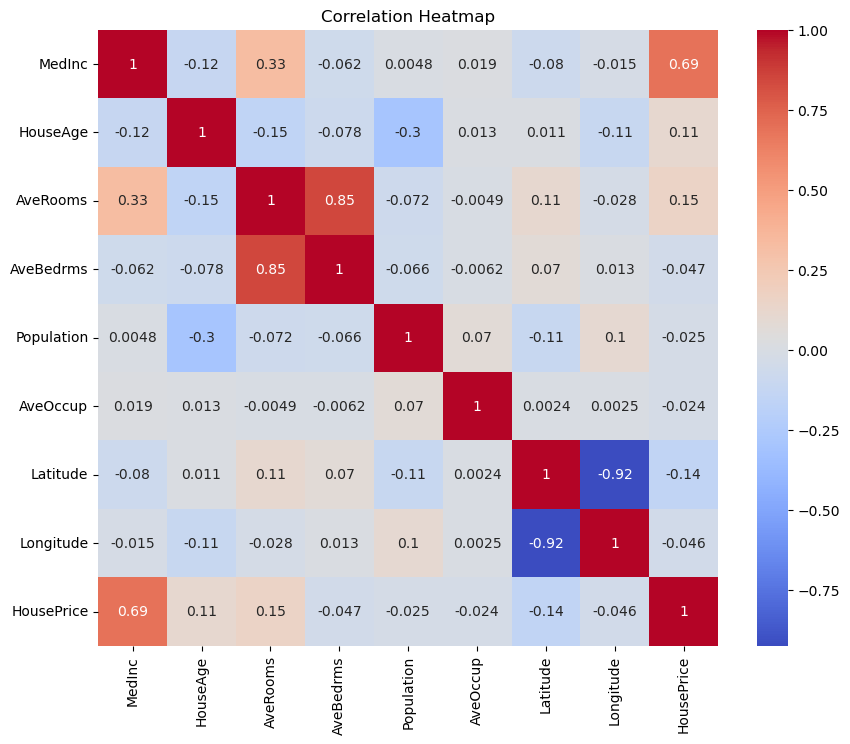

In [9]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

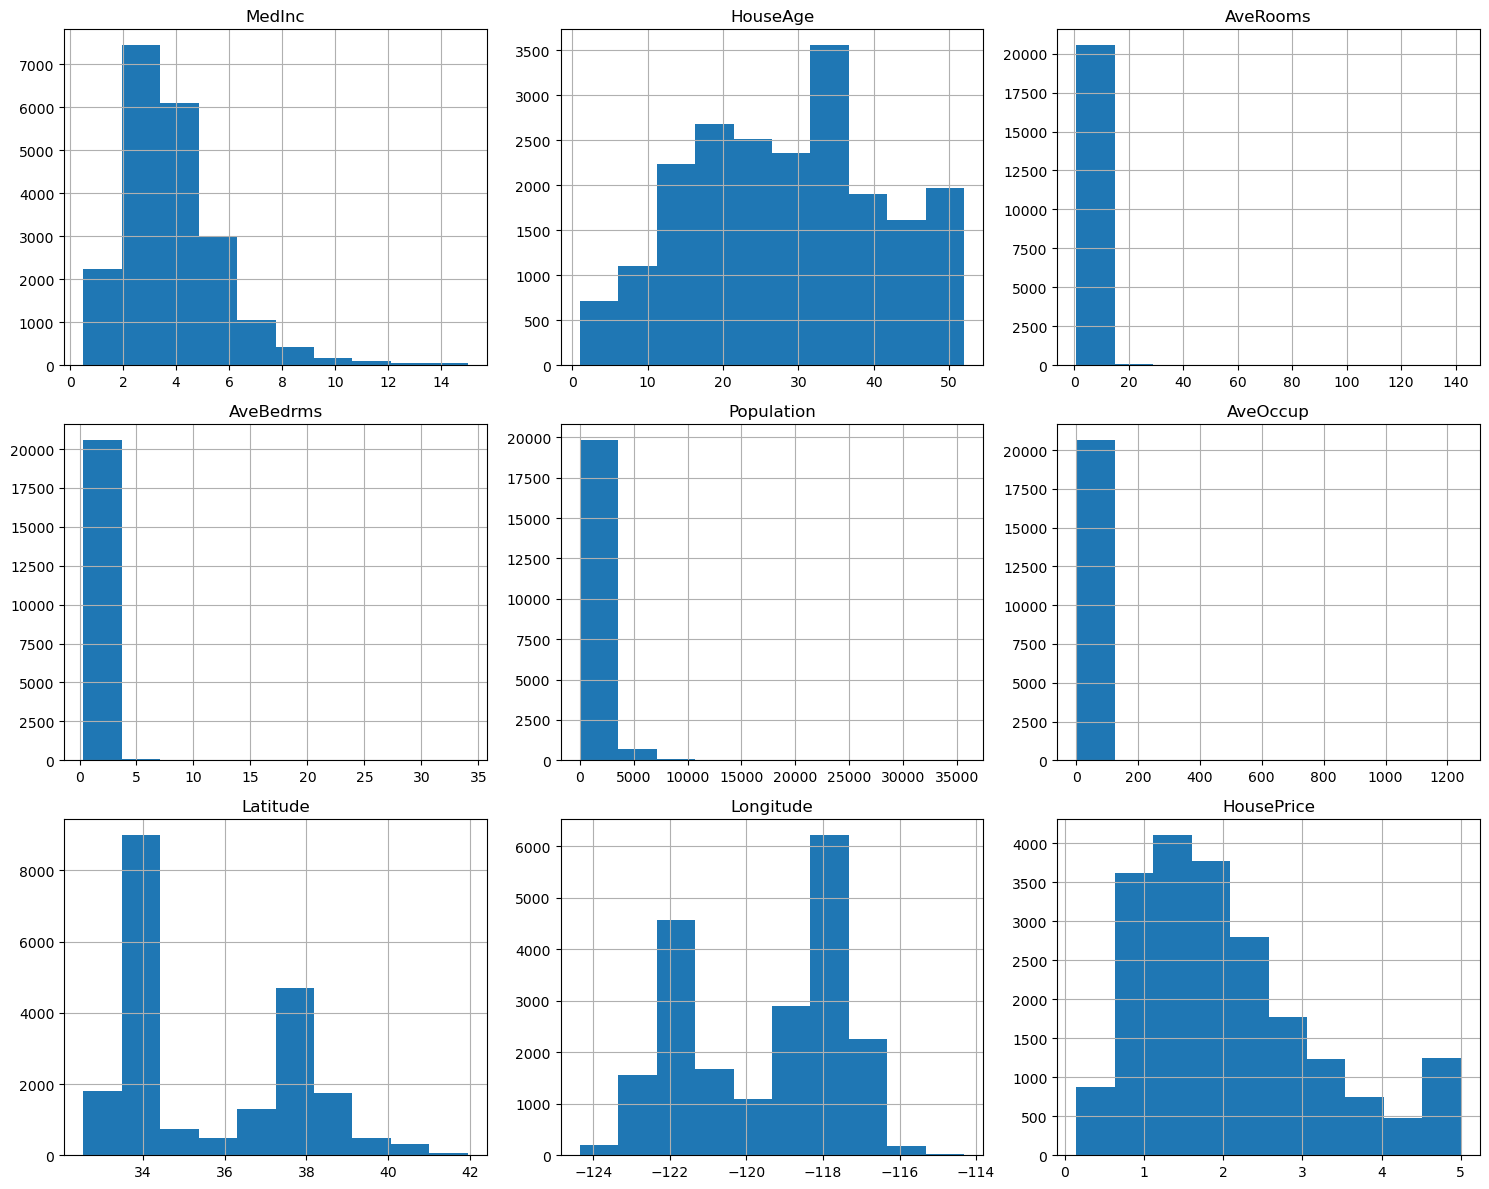

In [11]:
df.hist(figsize=(15,12))

plt.tight_layout()

plt.show()

In [12]:
X = df.drop("HousePrice", axis=1)

y = df["HousePrice"]

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [16]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

In [17]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [18]:
def evaluate_model(y_true, y_pred):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    return rmse, r2

In [19]:
lr_rmse, lr_r2 = evaluate_model(y_test, lr_pred)

ridge_rmse, ridge_r2 = evaluate_model(y_test, ridge_pred)

dt_rmse, dt_r2 = evaluate_model(y_test, dt_pred)

In [20]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Ridge Regression",
        "Decision Tree"
    ],

    "RMSE":[
        lr_rmse,
        ridge_rmse,
        dt_rmse
    ],

    "R2 Score":[
        lr_r2,
        ridge_r2,
        dt_r2
    ]

})

results

,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745554,0.575819
2,Decision Tree,0.703045,0.622811


In [21]:
results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,RMSE,R2 Score
2,Decision Tree,0.703045,0.622811
1,Ridge Regression,0.745554,0.575819
0,Linear Regression,0.745581,0.575788


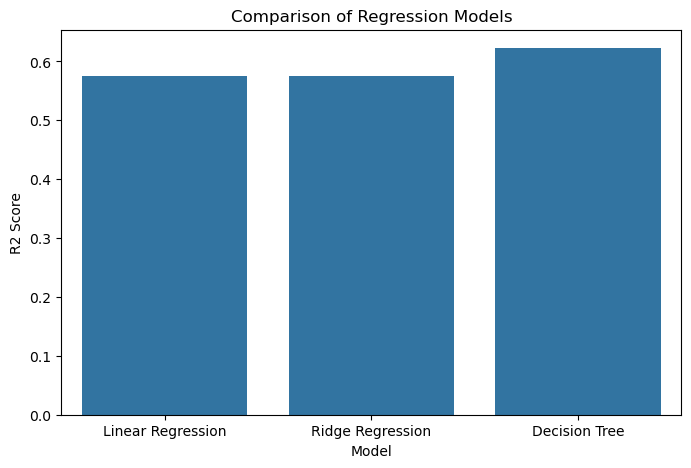

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score"
)

plt.title("Comparison of Regression Models")

plt.show()

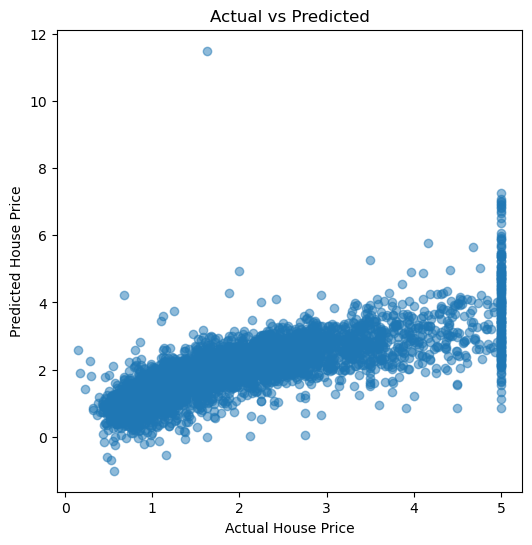

In [23]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    lr_pred,
    alpha=0.5
)

plt.xlabel("Actual House Price")

plt.ylabel("Predicted House Price")

plt.title("Actual vs Predicted")

plt.show()

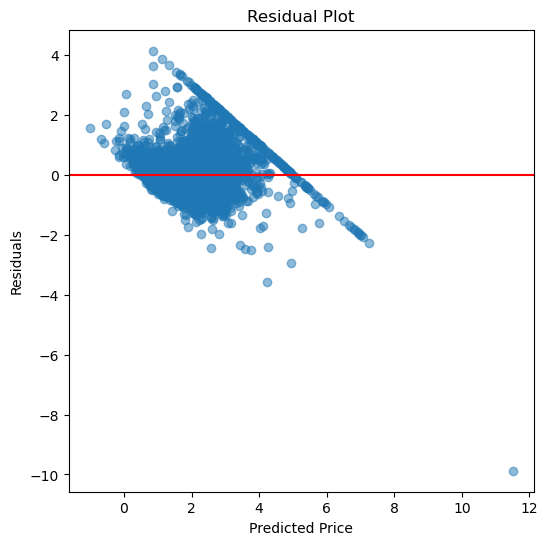

In [24]:
residuals = y_test - lr_pred

plt.figure(figsize=(6,6))

plt.scatter(
    lr_pred,
    residuals,
    alpha=0.5
)

plt.axhline(0,color="red")

plt.xlabel("Predicted Price")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [25]:
best_model = results.loc[
    results["R2 Score"].idxmax()
]

print("Best Performing Model")
print(best_model)

Best Performing Model
Model       Decision Tree
RMSE             0.703045
R2 Score         0.622811
Name: 2, dtype: object


In [26]:
print("Conclusion")
print("-"*50)

print("Three regression models were trained and evaluated.")

print("The comparison was based on RMSE and R² Score.")

print("The model with the highest R² Score and lowest RMSE is considered the best model for predicting California house prices.")

Conclusion
--------------------------------------------------
Three regression models were trained and evaluated.
The comparison was based on RMSE and R² Score.
The model with the highest R² Score and lowest RMSE is considered the best model for predicting California house prices.
